In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats

In [2]:
data_matrix = pd.read_csv("data/input/internship_data_matrix.csv", index_col=0) 
feature_metadata = pd.read_csv("data/input/internship_feature_metadata.csv", index_col=0) 
acquisition_list = pd.read_csv("data/input/intership_acquisition_list.csv", index_col=0)
standards_df = pd.read_csv("data/input/exogenous_standards.csv") 

In [3]:
print(f"Number of samples: {data_matrix.shape[0]}")
print(f"Number of features: {data_matrix.shape[1]}")

Number of samples: 124
Number of features: 252


# Identifying isomers and isotopes

First, we need to idenitfy suitable values to set as threshold for mz and rt. We assume that technical variability affects measurements, and therefore mz values that differ below a certain threshold can be considered equal (similarly for rt)

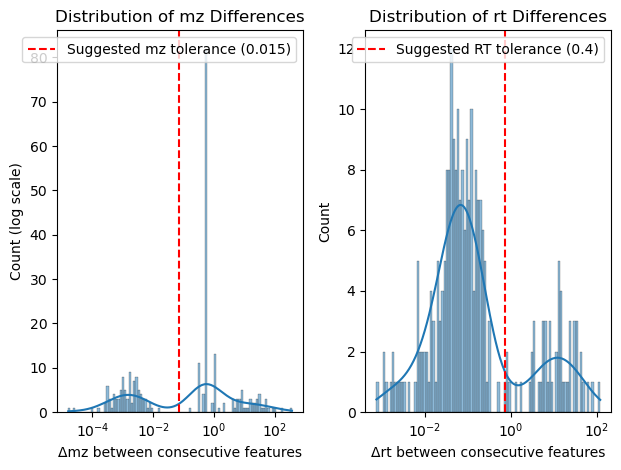

In [4]:
# Sort values
sorted_mz = np.sort(feature_metadata['mz'].unique())
sorted_rt = np.sort(feature_metadata['rt'].unique())

# Calculate differences of consecutive sorted values
mz_diffs = np.diff(sorted_mz)
rt_diffs = np.diff(sorted_rt)

# Tolerance values which I set based on histograms
MZ_TOLERANCE = 0.07
RT_TOLERANCE = 0.75

# Plot mz differences
plt.subplot(121)
sns.histplot(mz_diffs, bins=100, kde=True, log_scale=(True, False))
plt.axvline(x=MZ_TOLERANCE, color='r', linestyle='--', label='Suggested mz tolerance (0.015)')
plt.xlabel('Δmz between consecutive features')
plt.ylabel('Count (log scale)')
plt.title('Distribution of mz Differences')
plt.legend()

# Plot rt differences
plt.subplot(122)
sns.histplot(rt_diffs, bins=100, kde=True, log_scale=(True, False))
plt.axvline(x=RT_TOLERANCE, color='r', linestyle='--', label='Suggested RT tolerance (0.4)')
plt.xlabel('Δrt between consecutive features')
plt.title('Distribution of rt Differences')
plt.legend()

plt.tight_layout()
plt.show()

In [5]:
# Function for grouping values within a specified tolerance
def group_with_tolerance(values, tolerance):
    sorted_values = np.sort(values)
    groups = []
    current_group = [sorted_values[0]]
    
    for val in sorted_values[1:]:
        # Here we compare with the last value since it is the closest to our current value
        if val - current_group[-1] <= tolerance: 
            current_group.append(val)
        else:
            groups.append(current_group)
            current_group = [val]
    
    groups.append(current_group)
    return groups

# Group mz
unique_mz = feature_metadata["mz"].unique()
mz_groups = group_with_tolerance(unique_mz, MZ_TOLERANCE)

# Assign each feature to a group
feature_metadata["mz_group"] = -1  # Intialization
for group_id, group in enumerate(mz_groups):
    feature_metadata.loc[feature_metadata["mz"].isin(group), "mz_group"] = group_id

# Group rt
unique_rt = feature_metadata["rt"].unique()
rt_groups = group_with_tolerance(unique_rt, RT_TOLERANCE)

# Assign each feature to a group
feature_metadata["rt_group"] = -1  # Intialization
for group_id, group in enumerate(rt_groups):
    feature_metadata.loc[feature_metadata["rt"].isin(group), "rt_group"] = group_id

feature_metadata.head()

,mz,mz max,mz min,mz std,rt,rt end,rt max,rt min,rt start,rt std,mz_group,rt_group
feature,,,,,,,,,,,,
FT-000,359.108768,359.130591,359.090122,0.010955,543.846374,561.270879,546.697803,539.941156,528.714227,1.683901,3,0
FT-001,357.109546,357.130018,357.091871,0.010668,543.839157,563.021530,546.948017,540.038924,528.530311,1.662290,2,0
FT-002,889.649931,889.702216,889.601547,0.025552,609.099742,627.717251,611.746501,606.426553,596.789046,1.324647,21,1
FT-003,355.111928,355.132772,355.093653,0.010508,543.995269,566.951285,547.164503,540.681882,526.943213,1.609071,1,0
FT-004,888.645365,888.696941,888.600202,0.026161,609.255652,632.996442,612.008732,606.778809,595.461688,1.254684,20,1


As we can see above, each feature is now assgined an mz group ID and an rt group ID, we use that to compare if 2 features have the same mz/rt.

Now we can identify isomers:

In [6]:
# Group by mz group and count unique rt groups
isomer_candidates = feature_metadata.groupby('mz_group').filter(
    lambda x: x['rt_group'].nunique() > 1
)

print(f"Found {len(isomer_candidates)} potential isomer features")
print(f"Spanning {isomer_candidates['mz_group'].nunique()} unique m/z groups")

Found 154 potential isomer features
Spanning 61 unique m/z groups


And we can ientify isotopes:

In [7]:
# Group by rt group and count unique mz groups
isotope_candidates = feature_metadata.groupby('rt_group').filter(
    lambda x: x['mz_group'].nunique() > 1
)

print(f"Found {len(isotope_candidates)} potential isotope features")
print(f"Spanning {isotope_candidates['rt_group'].nunique()} unique RT groups")

Found 244 potential isotope features
Spanning 46 unique RT groups


# Correlation amongst isomers and amongst isotopes

Here we look for correlation amongst isomers. First we look at the top isomer group (most populated) and visualize correlation

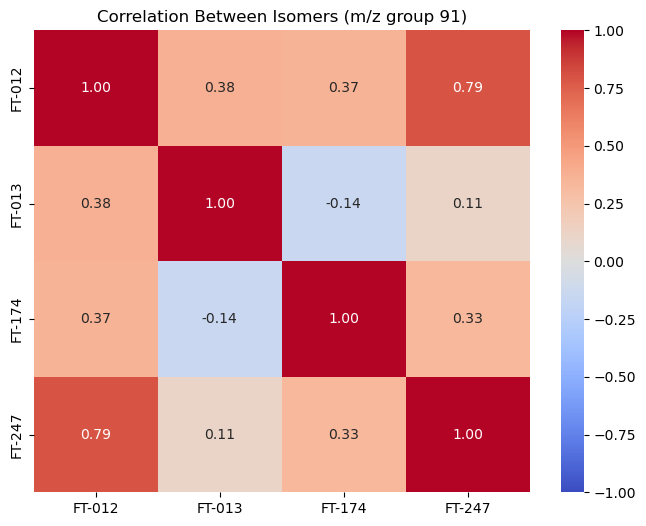

Isomer correlation stats (n=4):
Mean=0.48, Min=-0.14


In [8]:
# Select most populatd isomer group
top_isomer_cluster = isomer_candidates['mz_group'].value_counts().index[0]

# Extract features and calculate correlations
isomer_features = isomer_candidates[isomer_candidates['mz_group'] == top_isomer_cluster].index
isomer_corr = data_matrix[isomer_features].corr()

# Plot
plt.figure(figsize=(8,6))
sns.heatmap(isomer_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title(f"Correlation Between Isomers (m/z group {top_isomer_cluster})")
plt.show()

print(f"Isomer correlation stats (n={len(isomer_features)}):\nMean={isomer_corr.values.mean():.2f}, Min={isomer_corr.values.min():.2f}")

Now lets see for the average correlation amongst all isomer groups

In [9]:
isomer_corr_means = np.empty((isomer_candidates['mz_group'].nunique(), 2))

for i, cluster in enumerate(isomer_candidates['mz_group'].unique()):
    features_idx = isomer_candidates[isomer_candidates['mz_group'] == cluster].index
    corr = data_matrix[features_idx].corr()
    isomer_corr_means[i] = (corr.values.mean(), len(features_idx))
    
for length in np.unique(isomer_corr_means[:,1]):
    length_isomer_group_corr = isomer_corr_means[isomer_corr_means[:,1] == length][:,0]
    print(f"Mean correlation amongst isomoers (n_isomers={length:.0f} & n_isomer_groups={len(length_isomer_group_corr):.0f}) = {length_isomer_group_corr.mean():.2f}")
print(f"Mean correlation amongst isomoers = {isomer_corr_means[:,0].mean():.2f}")

Mean correlation amongst isomoers (n_isomers=2 & n_isomer_groups=33) = 0.93
Mean correlation amongst isomoers (n_isomers=3 & n_isomer_groups=24) = 0.85
Mean correlation amongst isomoers (n_isomers=4 & n_isomer_groups=4) = 0.71
Mean correlation amongst isomoers = 0.88


Similarly for isotopes:

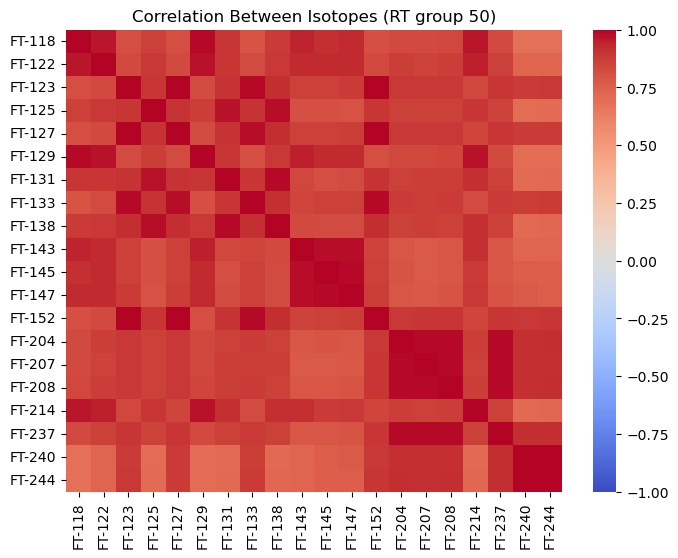

Isotope correlation stats (n=20):
Mean=0.87, Min=0.68


In [10]:
# Select most populatd isotope group
top_isotope_cluster = isotope_candidates['rt_group'].value_counts().index[0]  # Most populated RT group

# Extract features and calculate correlations

isotope_features = isotope_candidates[isotope_candidates['rt_group'] == top_isotope_cluster].index
isotope_corr = data_matrix[isotope_features].corr()

# Plot
plt.figure(figsize=(8,6))
sns.heatmap(isotope_corr, annot=False, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title(f"Correlation Between Isotopes (RT group {top_isotope_cluster})")
plt.show()

print(f"Isotope correlation stats (n={len(isotope_features)}):\nMean={isotope_corr.values.mean():.2f}, Min={isotope_corr.values.min():.2f}")

In [11]:
isotope_corr_means = np.empty((isotope_candidates['rt_group'].nunique(), 2))

for i, cluster in enumerate(isotope_candidates['rt_group'].unique()):
    features_idx = isotope_candidates[isotope_candidates['rt_group'] == cluster].index
    corr = data_matrix[features_idx].corr()
    isotope_corr_means[i] = (corr.values.mean(), len(features_idx))
    
for length in np.unique(isotope_corr_means[:,1]):
    length_isotope_group_corr = isotope_corr_means[isotope_corr_means[:,1] == length][:,0]
    print(f"Mean correlation amongst isotopes (n_isotopes={length:.0f} & n_isotope_groups={len(length_isotope_group_corr):.0f}) = {length_isotope_group_corr.mean():.2f}")
print(f"Mean correlation amongst isotopes = {isotope_corr_means[:,0].mean():.2f}")

Mean correlation amongst isotopes (n_isotopes=2 & n_isotope_groups=10) = 0.91
Mean correlation amongst isotopes (n_isotopes=3 & n_isotope_groups=10) = 0.91
Mean correlation amongst isotopes (n_isotopes=4 & n_isotope_groups=8) = 0.95
Mean correlation amongst isotopes (n_isotopes=5 & n_isotope_groups=1) = 0.99
Mean correlation amongst isotopes (n_isotopes=6 & n_isotope_groups=2) = 0.92
Mean correlation amongst isotopes (n_isotopes=7 & n_isotope_groups=4) = 0.82
Mean correlation amongst isotopes (n_isotopes=8 & n_isotope_groups=5) = 0.88
Mean correlation amongst isotopes (n_isotopes=9 & n_isotope_groups=2) = 0.94
Mean correlation amongst isotopes (n_isotopes=11 & n_isotope_groups=1) = 0.91
Mean correlation amongst isotopes (n_isotopes=12 & n_isotope_groups=1) = 0.95
Mean correlation amongst isotopes (n_isotopes=16 & n_isotope_groups=1) = 0.93
Mean correlation amongst isotopes (n_isotopes=20 & n_isotope_groups=1) = 0.87
Mean correlation amongst isotopes = 0.91


Here we see a high correlation amongst both isomers and isotopes. 

However for isomers, all groups are of small size (less than 4, with most being size 2), so we likely cannot draw any conclusions. Changing the threshold would affect results.

For isotopes, there are larger groups, however most groups are still of smaller size. Again, changing the threshold woulld affect results.

# Feature Detection

Once again we want to start by looking at the distribution of peaks so that we choose an appropriate detection threshold

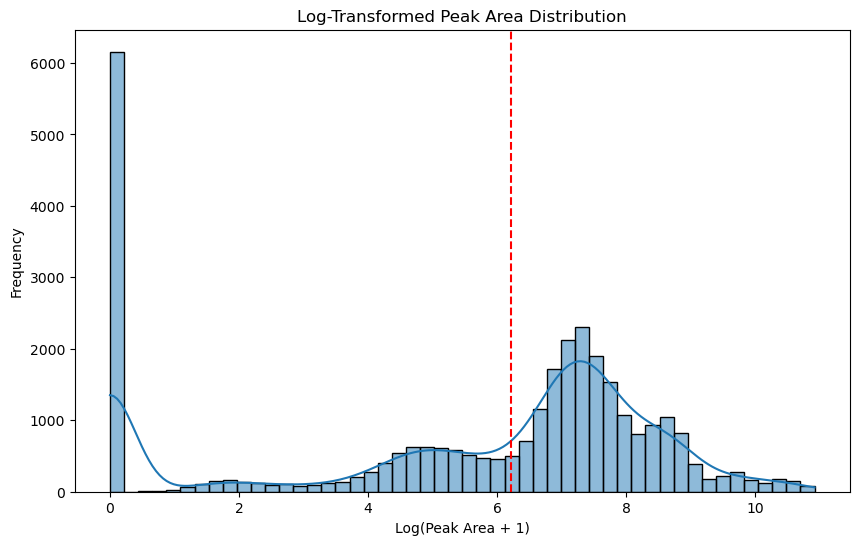

In [12]:
# I set the threshold after looking at the plot
DETECTION_THRESHOLD = 500

plt.figure(figsize=(10, 6))
sns.histplot(np.log1p(data_matrix.values.flatten()), bins=50, kde=True)
plt.axvline(x=np.log1p(DETECTION_THRESHOLD), color='r', linestyle='--')
plt.title("Log-Transformed Peak Area Distribution")
plt.xlabel("Log(Peak Area + 1)")
plt.ylabel("Frequency")
plt.show()

Now lets see how many features are detected

In [13]:
detected = data_matrix > DETECTION_THRESHOLD
detection_rate = detected.mean(axis=0)
avg_detection_rate = detection_rate.mean()

print(f"Total features detected: {(detection_rate > 0).sum()} out of {data_matrix.shape[1]}")
print(f"Features detected in >50% samples: {(detection_rate > 0.5).sum()}")
print(f"Average detection rate: {avg_detection_rate:.2f}")

Total features detected: 217 out of 252
Features detected in >50% samples: 189
Average detection rate: 0.58


Now we look at detection rate by mz and rt

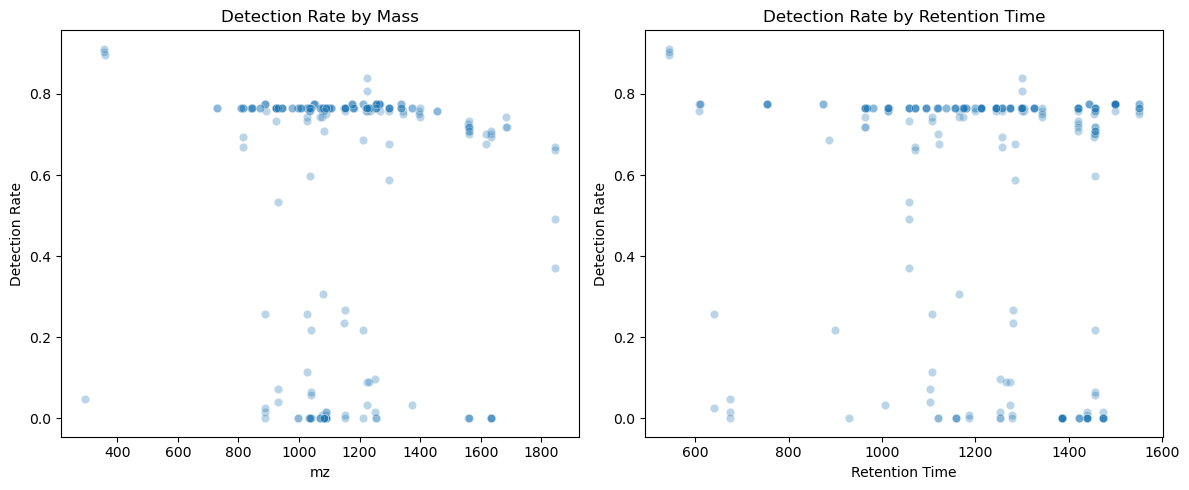

In [14]:
plt.figure(figsize=(12,5))

plt.subplot(121)
sns.scatterplot(x=feature_metadata['mz'], y=detection_rate, alpha=0.3)
plt.xlabel('mz')
plt.ylabel('Detection Rate')
plt.title('Detection Rate by Mass')

plt.subplot(122)
sns.scatterplot(x=feature_metadata['rt'], y=detection_rate, alpha=0.3)
plt.xlabel('Retention Time')
plt.ylabel('Detection Rate')
plt.title('Detection Rate by Retention Time')
plt.tight_layout()
plt.show()

We see 2 horizontal lines, indicating some features are likely to be detected across samples while others are not likely to be undetected. Both graphs indicate a lack of correlation between mz/rt and detection rate

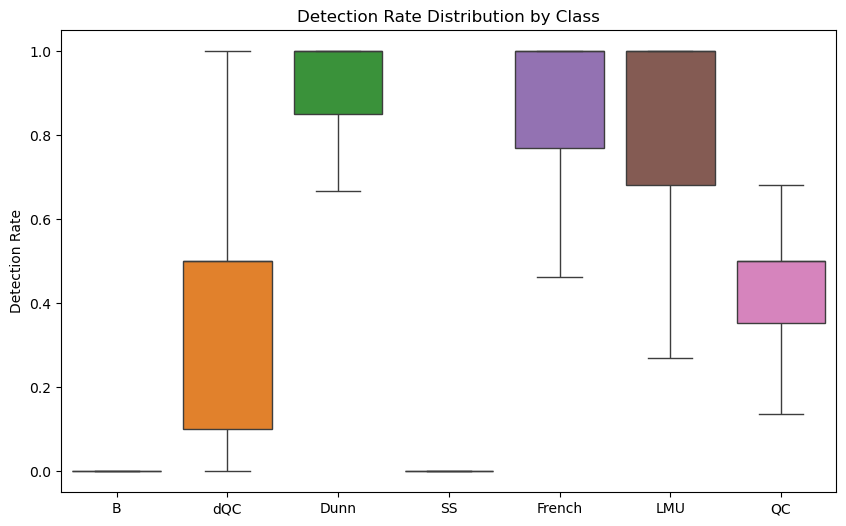

In [15]:
class_detection = {}

for class_name in acquisition_list['class'].unique():
    class_samples = acquisition_list[acquisition_list['class'] == class_name].index
    class_detection[class_name] = data_matrix.loc[class_samples].gt(DETECTION_THRESHOLD).mean(axis=0)

class_detection_df = pd.DataFrame(class_detection)

plt.figure(figsize=(10,6))
sns.boxplot(data=class_detection_df[acquisition_list['class'].unique()], showfliers=False)
plt.ylabel('Detection Rate')
plt.title('Detection Rate Distribution by Class')
plt.show()

In [16]:
qc_mean = class_detection_df[['QC', 'dQC']].mean().mean()
bio_mean = class_detection_df[['French','LMU','Dunn']].mean().mean()
blank_mean = class_detection_df['B'].mean().mean()

print(f"Mean detection rate:\n- QCs: {qc_mean:.2%}\n- Biological samples: {bio_mean:.2%}")
print(f"Fold difference: {bio_mean/qc_mean:.2f}x")
print(f"\n- Blank detection rate: {blank_mean:.2%}")

Mean detection rate:
- QCs: 37.91%
- Biological samples: 75.64%
Fold difference: 2.00x

- Blank detection rate: 0.00%


We see the 0% detection rate for blanks, which is expected. Also we see that the detection rate for biological samples is twice that of quality control samples.

# Contamination

To check contamination, we look at the detection rate for blank samples

In [17]:
blank_samples = acquisition_list[acquisition_list['class'] == 'B']
blank_intensity = data_matrix.loc[blank_samples.index]
contaminants = ((blank_intensity > 0).sum() > 0).sum()

print(f"Potential contaminants when comparing with zero: {contaminants} features")

Potential contaminants when comparing with zero: 44 features


Thoughts on how to mitigate contamination:
Look at blank samples, and use those readings to asses which features from the next samples should ignored/corrected.

# Standards detection

In [18]:
# Here we match the standards to corresponding feature using threshold
matched_standards = []

for _, row in standards_df.iterrows():
    matches = feature_metadata[
        (abs(feature_metadata['mz'] - row['mz']) < 1.0) &  # mz tolerance ±0.5
        (abs(feature_metadata['rt'] - row['Retention_time']) < 1.0)  # rt tolerance ±0.5
    ]
    if not matches.empty:
        matched_standards.append(matches.index[0])
        
standards_df['matching_feature'] = matched_standards
print(standards_df)

  compound_id       mz  Retention_time matching_feature
0         GU4   886.40             610           FT-005
1         GU5  1048.45             753           FT-010
2        GU14  1253.96            1500           FT-160
3        GU15  1334.99            1551           FT-169


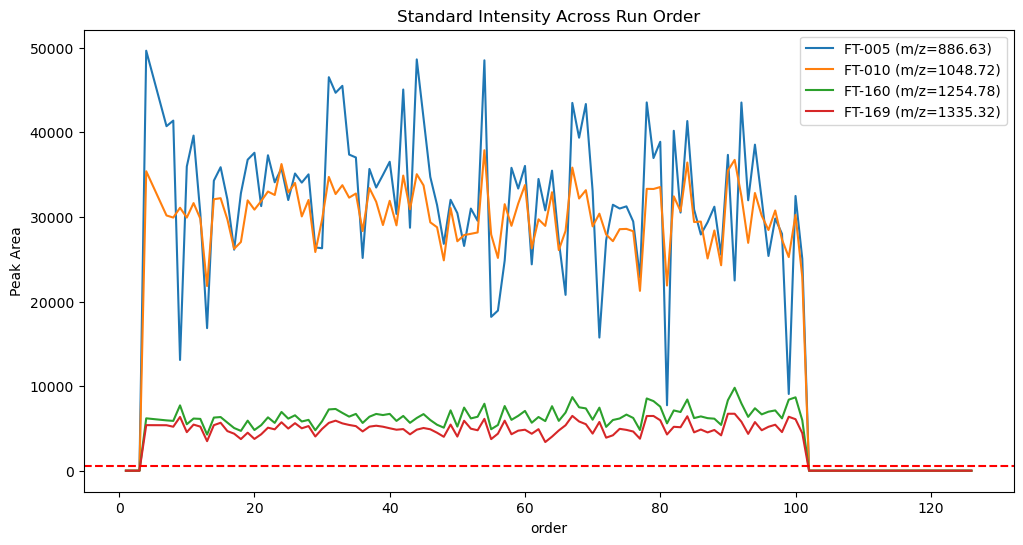

In [19]:
# Plot intensity trends for matched features
plt.figure(figsize=(12,6))
for std in matched_standards:
    sns.lineplot(
        x=acquisition_list['order'],
        y=data_matrix[std],
        label=f"{std} (m/z={feature_metadata.loc[std, 'mz']:.2f})"
    )
plt.axhline(DETECTION_THRESHOLD, color='r', linestyle='--')
plt.title("Standard Intensity Across Run Order")
plt.ylabel("Peak Area")
plt.legend()

From the graph we can assert the standards are consistently detected across the experiment, with some more than others.

# Intensity distribution

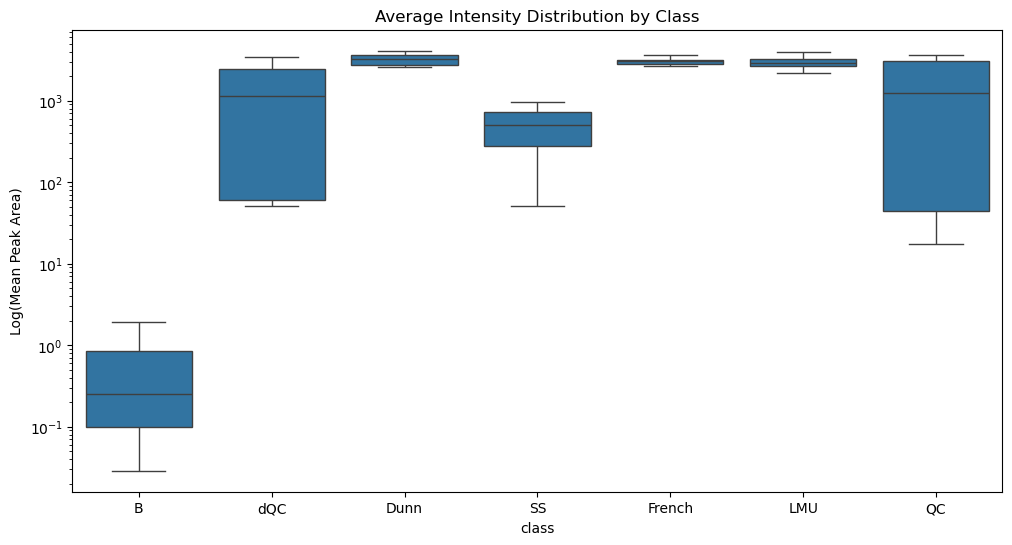

In [20]:
# Calculate mean intensity per sample
sample_means = data_matrix.mean(axis=1).rename('intensity').to_frame()
sample_means = sample_means.join(acquisition_list[['class', 'order']])

# Plot for class-wise distribution
plt.figure(figsize=(12,6))
sns.boxplot(
    data=sample_means,
    x='class',
    y='intensity',
    showfliers=False
)
plt.yscale('log')
plt.title('Average Intensity Distribution by Class')
plt.ylabel('Log(Mean Peak Area)')
plt.show()

Here we see what we expect, blanks having lower intensity values (nearing 0), while other samples having higher intensity values. Also QC samples have more intermediate and spread values. Suprisingly SS have higher values, however this graph does not show that there are only 2 samples in that class, with values around 50 and 950.

<Figure size 1400x600 with 0 Axes>

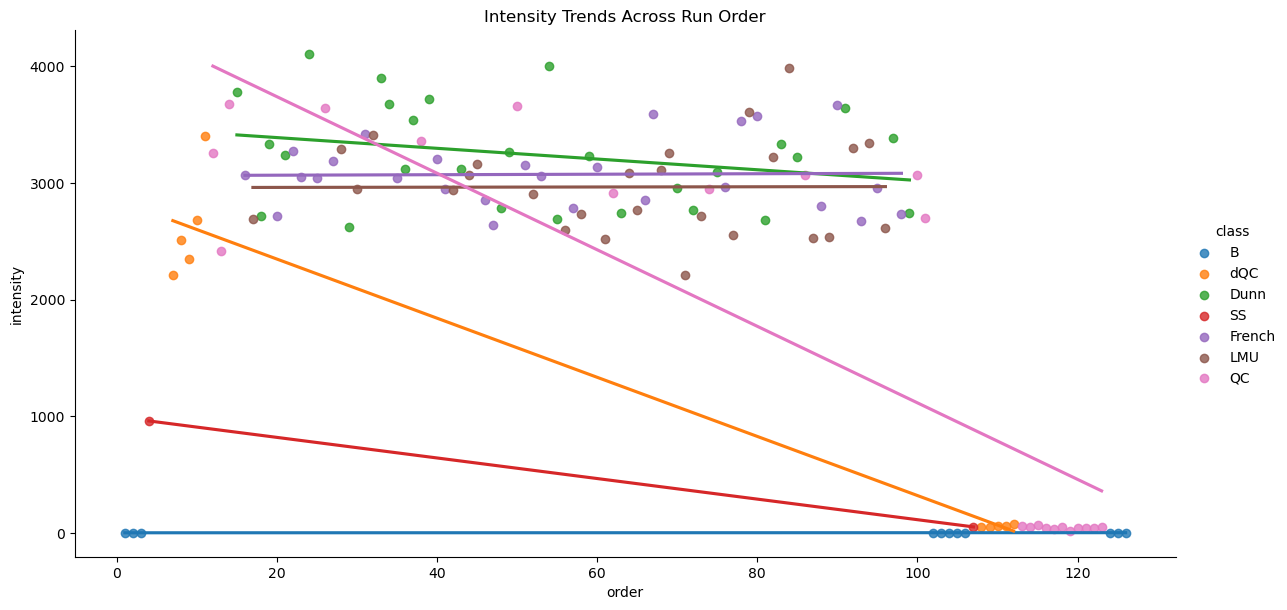

In [21]:
plt.figure(figsize=(14,6))
sns.lmplot(
    data=sample_means.reset_index(),
    x='order',
    y='intensity',
    hue='class',
    ci=None,
    order=1,
    height=6,
    aspect=2
)
plt.title('Intensity Trends Across Run Order')
plt.show()

For biological samples, we see that intensity is about the same across run order, which seems like what we want to see. As for blanks we see intensities around 0 across run order, which is expected. For SS, and QC, we see the intensity go down from the start to the end. For the case of the QC classes this is not good as we expecct the intensity to remain constant.

# QC between batches

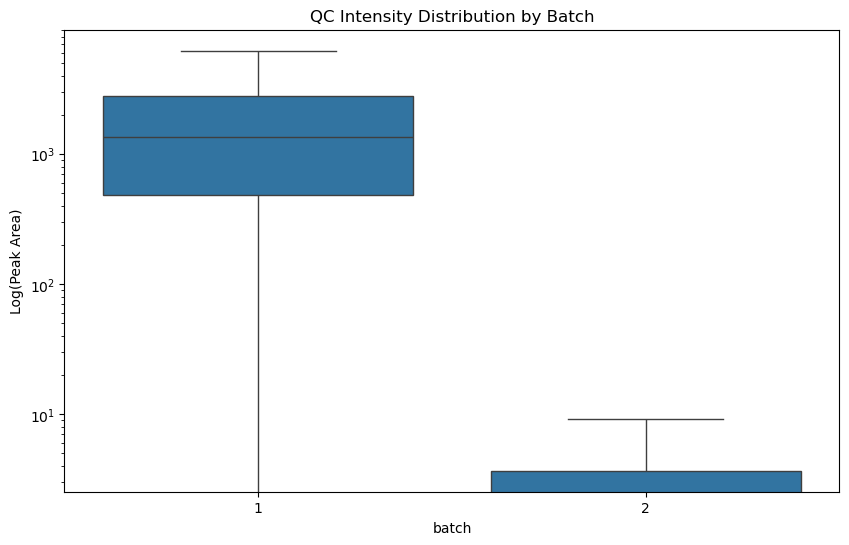

In [22]:
# Calculate mean QC intensities per batch
qc_data = data_matrix[acquisition_list['class'].isin(['QC', 'dQC'])]
batch_qc_means = qc_data.join(acquisition_list['batch']).groupby('batch').mean()

# Plot batch effects
plt.figure(figsize=(10,6))
sns.boxplot(
    data=qc_data.join(acquisition_list['batch']).melt(id_vars='batch', var_name='feature', value_name='intensity'),
    x='batch',
    y='intensity',
    showfliers=False
)
plt.yscale('log')
plt.title('QC Intensity Distribution by Batch')
plt.ylabel('Log(Peak Area)')
plt.show()

This is similar to what we saw from the plot for intensities across run order. We see that intially, in batch 1, intensities are where we expect for quality check. However for the second batch, intensities drop to very low values, which indicates that measurement stability is not as good as it should be.